# 🎌 Sistema de Recomendación de Anime — Parte 1: EDA y Preprocesamiento
**Persona 1 — Líder de datos**  
Este notebook genera los splits de train/test que usarán todas las personas del equipo.

---
## Contenido
1. Carga de datos
2. Exploración (EDA)
3. Preprocesamiento
4. Modelo Base (Baseline)
5. Guardado de splits para el equipo

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
print('Imports OK')

Imports OK


## 1. Carga de Datos

In [2]:
# Carga de los dos datasets
# ⚠️  Asegúrate de que anime.csv y rating.csv están en la misma carpeta que este notebook
# Descarga en: https://www.kaggle.com/datasets/CooperUnion/anime-recommendations-database/data

anime_df = pd.read_csv('dataset_anime/anime.csv')
rating_df = pd.read_csv('dataset_anime/rating.csv')

print(f'anime.csv   → {anime_df.shape[0]:,} filas, {anime_df.shape[1]} columnas')
print(f'rating.csv  → {rating_df.shape[0]:,} filas, {rating_df.shape[1]} columnas')

anime.csv   → 12,294 filas, 7 columnas
rating.csv  → 7,813,737 filas, 3 columnas


In [3]:
# Vista rápida de ambos datasets
print('=== anime.csv ===')
display(anime_df.head())
print()
print('=== rating.csv ===')
display(rating_df.head())

=== anime.csv ===


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266



=== rating.csv ===


,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


## 2. EDA — Análisis Exploratorio

In [4]:
# -------------------------------------------------------
# 2.1 Estadísticas básicas de anime.csv
# -------------------------------------------------------
print('== Tipos y valores nulos en anime.csv ==')
print(anime_df.dtypes)
print()
print('Valores nulos:')
print(anime_df.isnull().sum())
print()
display(anime_df.describe())

== Tipos y valores nulos en anime.csv ==
anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

Valores nulos:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64



,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [5]:
# -------------------------------------------------------
# 2.2 Estadísticas básicas de rating.csv
# -------------------------------------------------------
print('== Tipos y valores nulos en rating.csv ==')
print(rating_df.dtypes)
print()
print('Valores nulos:')
print(rating_df.isnull().sum())
print()
display(rating_df.describe())

# Usuarios únicos e ítems únicos
n_users  = rating_df['user_id'].nunique()
n_items  = rating_df['anime_id'].nunique()
n_ratings = len(rating_df)
sparsity = 1 - n_ratings / (n_users * n_items)

print(f'\nUsuarios únicos : {n_users:,}')
print(f'Animes únicos   : {n_items:,}')
print(f'Total ratings   : {n_ratings:,}')
print(f'Sparsity        : {sparsity:.4%}')  # Cuánto vacío tiene la matriz

== Tipos y valores nulos en rating.csv ==
user_id     int64
anime_id    int64
rating      int64
dtype: object

Valores nulos:
user_id     0
anime_id    0
rating      0
dtype: int64



,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01



Usuarios únicos : 73,515
Animes únicos   : 11,200
Total ratings   : 7,813,737
Sparsity        : 99.0510%


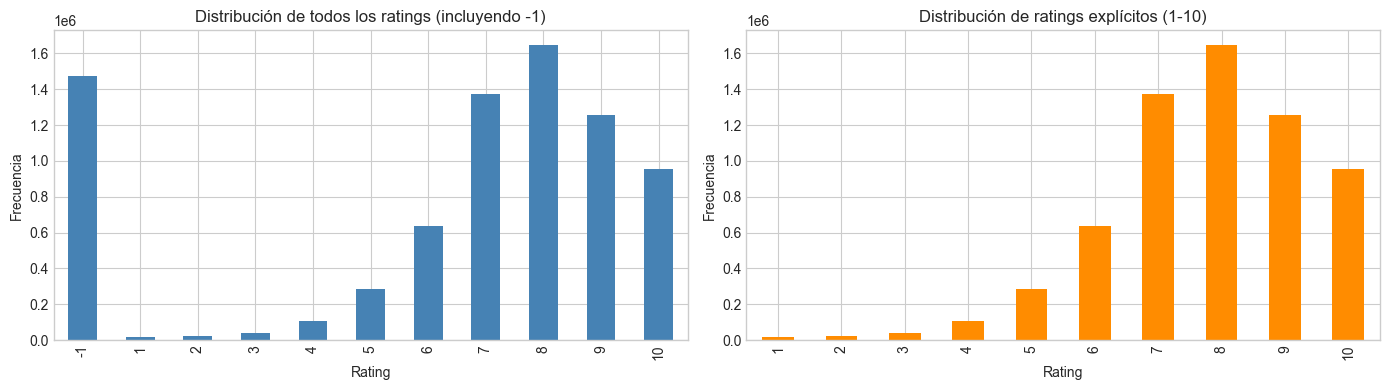

Ratings implícitos (-1): 18.90% del total


In [6]:
# -------------------------------------------------------
# 2.3 Distribución de ratings (incluyendo -1 = visto sin puntuar)
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Todos los valores incluyendo -1
rating_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de todos los ratings (incluyendo -1)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frecuencia')

# Solo ratings explícitos (1-10)
explicit = rating_df[rating_df['rating'] != -1]['rating']
explicit.value_counts().sort_index().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Distribución de ratings explícitos (1-10)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('fig_distribucion_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

pct_implicit = (rating_df['rating'] == -1).mean()
print(f'Ratings implícitos (-1): {pct_implicit:.2%} del total')

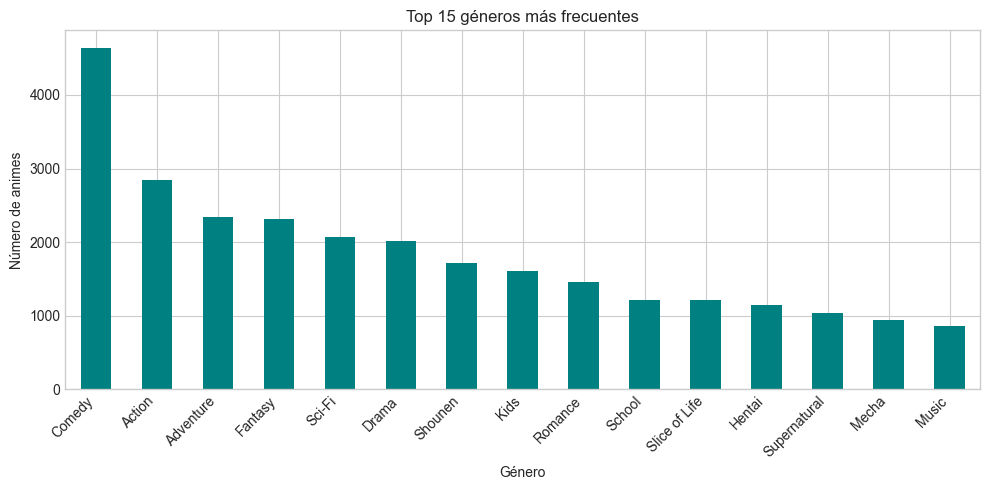

In [7]:
# -------------------------------------------------------
# 2.4 Géneros más frecuentes
# -------------------------------------------------------
# Cada anime puede tener múltiples géneros separados por coma
genres = anime_df['genre'].dropna().str.split(', ').explode()
top_genres = genres.value_counts().head(15)

plt.figure(figsize=(10, 5))
top_genres.plot(kind='bar', color='teal')
plt.title('Top 15 géneros más frecuentes')
plt.xlabel('Género')
plt.ylabel('Número de animes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_top_generos.png', dpi=150, bbox_inches='tight')
plt.show()

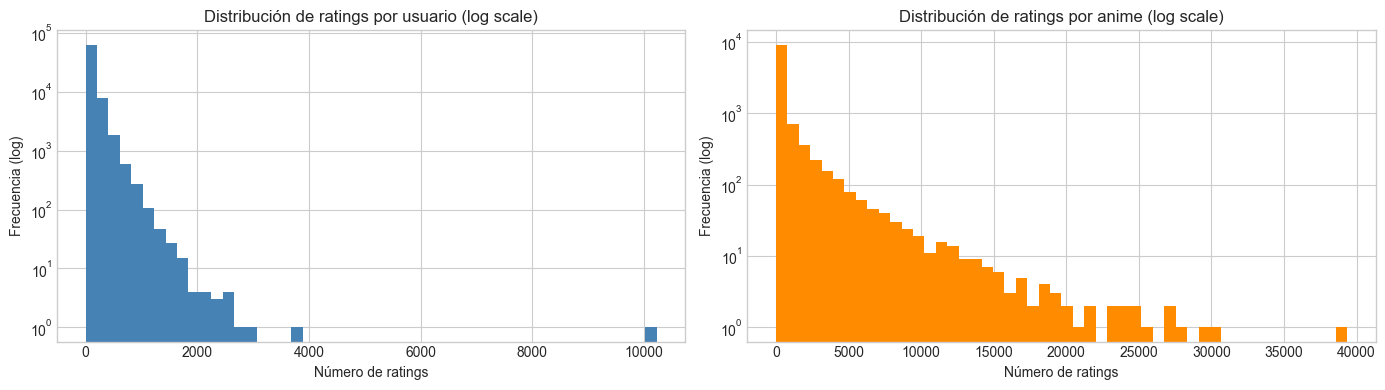

Media de ratings por usuario : 106.3
Mediana de ratings por usuario: 57
Media de ratings por anime   : 697.7
Mediana de ratings por anime  : 52


In [8]:
# -------------------------------------------------------
# 2.5 Ratings por usuario y por ítem (detección de cold start)
# -------------------------------------------------------
ratings_per_user = rating_df.groupby('user_id')['rating'].count()
ratings_per_item = rating_df.groupby('anime_id')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ratings_per_user, bins=50, color='steelblue', log=True)
axes[0].set_title('Distribución de ratings por usuario (log scale)')
axes[0].set_xlabel('Número de ratings')
axes[0].set_ylabel('Frecuencia (log)')

axes[1].hist(ratings_per_item, bins=50, color='darkorange', log=True)
axes[1].set_title('Distribución de ratings por anime (log scale)')
axes[1].set_xlabel('Número de ratings')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.savefig('fig_ratings_por_usuario_item.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Media de ratings por usuario : {ratings_per_user.mean():.1f}')
print(f'Mediana de ratings por usuario: {ratings_per_user.median():.0f}')
print(f'Media de ratings por anime   : {ratings_per_item.mean():.1f}')
print(f'Mediana de ratings por anime  : {ratings_per_item.median():.0f}')

## 3. Preprocesamiento

Generamos **dos versiones** del dataset:

| Versión | Uso | Ratings |
|---|---|---|
| `ratings_explicit` | CF (KNN) y SVD | Solo 1-10 (sin -1) |
| `ratings_binary` | Bernoulli MF | Binarizado: ≥7 → 1, resto → 0 |

In [9]:
# -------------------------------------------------------
# 3.1 Filtrado de cold start
# Eliminamos usuarios e ítems con muy pocos ratings
# para que los modelos tengan suficiente señal
# -------------------------------------------------------
MIN_RATINGS_USER = 50   # un usuario debe haber valorado al menos 50 animes
MIN_RATINGS_ITEM = 50   # un anime debe tener al menos 50 valoraciones

# Partimos de ratings explícitos (sin -1)
df_explicit = rating_df[rating_df['rating'] != -1].copy()

print(f'Antes del filtrado: {len(df_explicit):,} ratings')

# Iteramos hasta estabilizar (porque al eliminar usuarios, cambia el conteo de ítems y viceversa)
for i in range(5):
    # Filtrar usuarios
    user_counts = df_explicit['user_id'].value_counts()
    valid_users = user_counts[user_counts >= MIN_RATINGS_USER].index
    df_explicit = df_explicit[df_explicit['user_id'].isin(valid_users)]

    # Filtrar ítems
    item_counts = df_explicit['anime_id'].value_counts()
    valid_items = item_counts[item_counts >= MIN_RATINGS_ITEM].index
    df_explicit = df_explicit[df_explicit['anime_id'].isin(valid_items)]

print(f'Después del filtrado: {len(df_explicit):,} ratings')
print(f'Usuarios: {df_explicit["user_id"].nunique():,}')
print(f'Animes  : {df_explicit["anime_id"].nunique():,}')

# Nueva sparsity
n_u = df_explicit['user_id'].nunique()
n_i = df_explicit['anime_id'].nunique()
sparsity_new = 1 - len(df_explicit) / (n_u * n_i)
print(f'Sparsity tras filtrado: {sparsity_new:.4%}')

Antes del filtrado: 6,337,241 ratings
Después del filtrado: 5,630,074 ratings
Usuarios: 32,925
Animes  : 5,133
Sparsity tras filtrado: 96.6687%


In [10]:
# -------------------------------------------------------
# 3.2 Re-indexar user_id y anime_id como índices enteros continuos
# Esto es necesario para matrices y modelos de MF
# -------------------------------------------------------
user_ids  = {uid: idx for idx, uid in enumerate(df_explicit['user_id'].unique())}
anime_ids = {aid: idx for idx, aid in enumerate(df_explicit['anime_id'].unique())}

df_explicit = df_explicit.copy()
df_explicit['user_idx']  = df_explicit['user_id'].map(user_ids)
df_explicit['anime_idx'] = df_explicit['anime_id'].map(anime_ids)

N_USERS = df_explicit['user_idx'].nunique()
N_ITEMS = df_explicit['anime_idx'].nunique()
print(f'Dimensiones de la matriz: {N_USERS} usuarios × {N_ITEMS} animes')

Dimensiones de la matriz: 32925 usuarios × 5133 animes


In [11]:
# -------------------------------------------------------
# 3.3 Train / Test split (80/20 estratificado por usuario)
# -------------------------------------------------------
train_data, test_data = train_test_split(
    df_explicit,
    test_size=0.2,
    random_state=42,
    stratify=df_explicit['user_idx']  # Asegura que todos los usuarios están en ambos splits
)

print(f'Train: {len(train_data):,} ratings')
print(f'Test : {len(test_data):,} ratings')

# Verificamos que todos los usuarios del test están en train
test_users_in_train = test_data['user_idx'].isin(train_data['user_idx']).all()
print(f'Todos los usuarios del test están en train: {test_users_in_train}')

Train: 4,504,059 ratings
Test : 1,126,015 ratings
Todos los usuarios del test están en train: True


In [12]:
# -------------------------------------------------------
# 3.4 Dataset binario para Bernoulli MF
# Binarización: rating >= 7 → 1 (le gustó), resto → 0
# También incluimos los -1 (visto sin puntuar) como 0
# -------------------------------------------------------

# Incluir también los implícitos (-1) que pasaron el filtro de cold start
df_all = rating_df[
    rating_df['user_id'].isin(user_ids.keys()) &
    rating_df['anime_id'].isin(anime_ids.keys())
].copy()

# Binarización
df_all['binary_rating'] = (df_all['rating'] >= 7).astype(int)
# Los -1 quedan como 0 (lo cual es correcto: visto pero sin puntuar positivo)

df_all['user_idx']  = df_all['user_id'].map(user_ids)
df_all['anime_idx'] = df_all['anime_id'].map(anime_ids)

# Split para BMF
train_binary, test_binary = train_test_split(
    df_all[['user_idx', 'anime_idx', 'binary_rating']],
    test_size=0.2,
    random_state=42
)

print(f'Positivos (1): {df_all["binary_rating"].sum():,} ({df_all["binary_rating"].mean():.2%})')
print(f'Negativos (0): {(df_all["binary_rating"] == 0).sum():,}')

Positivos (1): 4,624,749 (75.84%)
Negativos (0): 1,473,200


## 4. Modelo Base (Baseline)
El baseline siempre predice la media. Es el punto de referencia mínimo que cualquier modelo debe superar.

In [13]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

y_test = test_data['rating'].values

# -------------------------------------------------------
# 4.1 Global Mean Baseline
# Predice la media global para cualquier (usuario, ítem)
# -------------------------------------------------------
global_mean = train_data['rating'].mean()
pred_global = np.full(len(y_test), global_mean)

rmse_global = rmse(y_test, pred_global)
mae_global  = mae(y_test, pred_global)
print(f'Media global: {global_mean:.3f}')
print(f'RMSE (global mean): {rmse_global:.4f}')
print(f'MAE  (global mean): {mae_global:.4f}')

Media global: 7.766
RMSE (global mean): 1.5587
MAE  (global mean): 1.2243


In [14]:
# -------------------------------------------------------
# 4.2 Item Mean Baseline
# Predice la media del anime; si no existe en train, usa la global
# -------------------------------------------------------
item_mean = train_data.groupby('anime_idx')['rating'].mean()

pred_item = test_data['anime_idx'].map(item_mean).fillna(global_mean).values

rmse_item = rmse(y_test, pred_item)
mae_item  = mae(y_test, pred_item)
print(f'RMSE (item mean): {rmse_item:.4f}')
print(f'MAE  (item mean): {mae_item:.4f}')

RMSE (item mean): 1.4274
MAE  (item mean): 1.1032


In [15]:
# -------------------------------------------------------
# 4.3 User Mean Baseline
# Predice la media del usuario; si no existe, usa la global
# -------------------------------------------------------
user_mean = train_data.groupby('user_idx')['rating'].mean()

pred_user = test_data['user_idx'].map(user_mean).fillna(global_mean).values

rmse_user = rmse(y_test, pred_user)
mae_user  = mae(y_test, pred_user)
print(f'RMSE (user mean): {rmse_user:.4f}')
print(f'MAE  (user mean): {mae_user:.4f}')

RMSE (user mean): 1.3571
MAE  (user mean): 1.0409


=== TABLA BASELINE ===


,Modelo,RMSE,MAE
0,Global Mean,1.5587,1.2243
1,Item Mean,1.4274,1.1032
2,User Mean,1.3571,1.0409


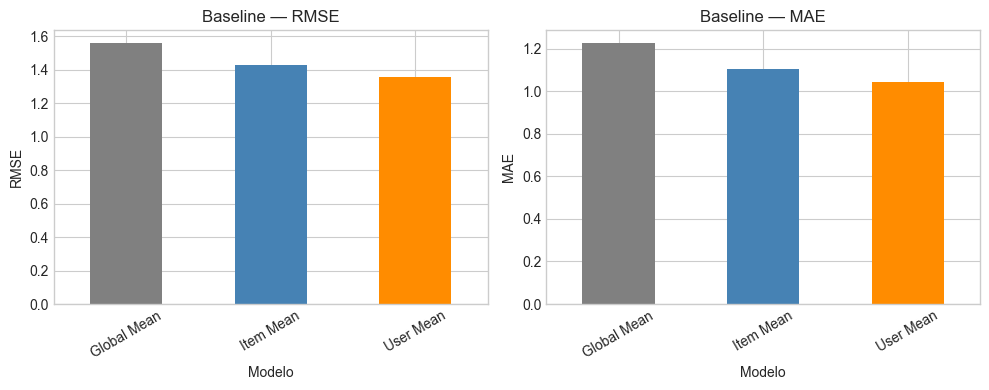

In [16]:
# -------------------------------------------------------
# 4.4 Resumen del baseline
# -------------------------------------------------------
baseline_results = pd.DataFrame({
    'Modelo':  ['Global Mean', 'Item Mean', 'User Mean'],
    'RMSE':    [rmse_global, rmse_item, rmse_user],
    'MAE':     [mae_global,  mae_item,  mae_user]
})

print('=== TABLA BASELINE ===')
display(baseline_results.round(4))

# Gráfica de comparación baseline
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
baseline_results.set_index('Modelo')['RMSE'].plot(kind='bar', ax=axes[0], color=['gray','steelblue','darkorange'])
axes[0].set_title('Baseline — RMSE')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)

baseline_results.set_index('Modelo')['MAE'].plot(kind='bar', ax=axes[1], color=['gray','steelblue','darkorange'])
axes[1].set_title('Baseline — MAE')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_baseline_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Guardado de Splits para el Equipo
⚠️ **IMPORTANTE**: Ejecuta esta sección y comparte los archivos `.pkl` con el resto del equipo.  
P2 (KNN), P3 (SVD) y P4 (BMF) deben usar exactamente estos mismos splits para que las métricas sean comparables.

In [ ]:
import pickle

# Guardamos todo lo que necesitan los demás
shared = {
    # Splits explícitos para KNN y SVD
    'train_data':    train_data,
    'test_data':     test_data,
    # Splits binarios para BMF
    'train_binary':  train_binary,
    'test_binary':   test_binary,
    # Mappings de IDs originales a índices
    'user_ids':      user_ids,
    'anime_ids':     anime_ids,
    # Dimensiones de la matriz
    'N_USERS':       N_USERS,
    'N_ITEMS':       N_ITEMS,
    # Media global (para fallback en todos los modelos)
    'global_mean':   global_mean,
    # Métricas baseline de referencia
    'baseline_results': baseline_results
}

with open('shared_splits.pkl', 'wb') as f:
    pickle.dump(shared, f)

print('✅ shared_splits.pkl guardado correctamente')
print()
print('Contenido del archivo compartido:')
for k, v in shared.items():
    if hasattr(v, '__len__'):
        print(f'  {k}: {type(v).__name__} de tamaño {len(v)}')
    else:
        print(f'  {k}: {v}')

In [ ]:
# -------------------------------------------------------
# Cómo cargar los splits en los otros notebooks (P2, P3, P4)
# -------------------------------------------------------
# import pickle
# with open('shared_splits.pkl', 'rb') as f:
#     data = pickle.load(f)
#
# train_data   = data['train_data']
# test_data    = data['test_data']
# train_binary = data['train_binary']
# test_binary  = data['test_binary']
# user_ids     = data['user_ids']
# anime_ids    = data['anime_ids']
# N_USERS      = data['N_USERS']
# N_ITEMS      = data['N_ITEMS']
# global_mean  = data['global_mean']
print('Snippet de carga listo para copiar a los demás notebooks')